In [5]:
# Standard Library
import random
import time

# Data Processing
import numpy as np
import pandas as pd
from numpy import inf

# Visualization
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from mpl_toolkits import mplot3d

# Machine Learning
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import f1_score, accuracy_score
from sklearn.svm import SVC

# Dimensionality Reduction & Utilities
import umap
from joblib import Parallel, delayed

# Feature Selection
from testflows.combinatorics import Covering
from Py_FS.wrapper.population_based.BBA import BBA as BBA
from Py_FS.wrapper.population_based.PSO import PSO as PSO
from Py_FS.wrapper.population_based.CS import CS as CS

# Datasets

In [6]:
df_cis = pd.read_csv('../data/cis_data.csv')
df_cacao = pd.read_csv(r'../data/data_temp/cacao.csv')
df_algarrobo = pd.read_csv(r'../data/data_temp/algarrobo.csv')
df_fruits_pures = pd.read_csv(r'../data/data_temp/MIR_Fruit_purees.csv')
df_fresh_meat = pd.read_csv(r'../data/data_temp/Fresh_meats.csv')
df_olive = pd.read_csv(r'../data/data_temp/Olive_Oils_Quadrum.csv')


df_x_cacao = df_cacao.iloc[:, 1:]
y_cacao = df_cacao.iloc[:, 0:1]

unique_names_algarrobo = df_algarrobo['Labels'].unique()
algarrobo_x = df_algarrobo.loc[:, 'R':'REDVI']
y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1]).to_frame()

cis_x = df_cis[['X', 'Y', 'X10', 'Y10', 'X20', 'Y20', 'X30', 'Y30', 'X40', 'Y40']]
y_cis = df_cis[['Result']]

unique_names_berry = df_fruits_pures["label"].unique()
fruits_pures_x = df_fruits_pures.iloc[:,1:]
y_fruit_puree = df_fruits_pures.iloc[:,0:1].replace(to_replace=unique_names_berry, value =range(0,len(unique_names_berry)))


unique_names_meat = df_fresh_meat["meat"].unique()
meat_x = df_fresh_meat.iloc[:,4:]
y_meat = df_fresh_meat.iloc[:,0:1].replace(to_replace=unique_names_meat,value=range(0,len(unique_names_meat)))

unique_names_olive = df_olive["Provenance"].unique()
olive_x = df_olive.iloc[:,3:]
y_olive = df_olive.iloc[:,2:3].replace(to_replace=unique_names_olive,value=range(0,len(unique_names_olive)))

covering_array  = np.loadtxt(r'../data/coveringArray.csv', delimiter=",", dtype=int)

# ICAFS/CAFS Base Function

In [7]:
def ICAFS(dataset_X, dataset_Y, strenght,max_iteartion,model, print_logs=False):
  
  max_it = 1 

  v_variable = [0, 1]
  best_f1_score = float('-inf')
  max_iteartion_aux =  max_iteartion
  best_data_set = dataset_X.columns.values.copy()

  global_best_score = float('-inf')
  global_best_features = dataset_X.columns.values.copy()

  while max_iteartion_aux > 0:
      
      partial_score = 0
      dict_parameters = {}
      lst_of_featutres_to_check = []

      for colum_key in best_data_set:
          dict_parameters[colum_key] = v_variable
      generate_covering_array = Covering(dict_parameters, strength=strenght)
      for i,test in  enumerate(generate_covering_array.array):
          list_attributes_to_consider = []

          check_for_all_cero = True
          for (test_key, test_value) in test.items():
              if test_value == 1:
                  check_for_all_cero = False
                  list_attributes_to_consider.append(test_key)

          if check_for_all_cero:
              continue  
          lst_of_featutres_to_check.append((list_attributes_to_consider,i))
      
      clf_new = train_model(model)
      results = Parallel(n_jobs=-1)(delayed(run_cv)(clf_new, dataset_X, subset_features, dataset_Y.values.ravel(), i) for subset_features,i in lst_of_featutres_to_check)   
      sorted_results = sorted(results, key=lambda x: x[2])
      
      for score, std, i, subset_features in sorted_results:
        if score >= partial_score:
              partial_score = score
              best_std = std
              best_data_set = subset_features.copy()
      
      if partial_score >= global_best_score:
            global_best_score = partial_score
            global_best_features = best_data_set.copy()

      clf_new = None
      best_f1_score = partial_score
      
      if print_logs:
        print(f"best f1 score= {best_f1_score}, iteration:{max_it}, numbers features selected ={ len(best_data_set)},best features selected={', '.join(best_data_set)}" )

      max_it = max_it +1
      max_iteartion_aux = max_iteartion_aux-1
  return global_best_features

def train_model(model_name):  

    m = eval(model_name)
    return m

def run_cv(model, X, subset_features, y, index):

    scores = cross_val_score(model, X[subset_features].values, y, cv=5, scoring='f1_macro',n_jobs=1)
    return (scores.mean(), scores.std(), index, subset_features)

In [8]:
def CAFS(ca,dataset_x,dataset_y, max_iter ,clasifier,print_logs=False):

  max_iteartion = 0
  num_rows = ca.shape[0]
  next_features_data_set_selected = dataset_x.columns.values.copy()

  best_score_global = float('-inf')
  best_features_global = dataset_x.columns.values.copy()

  if len(dataset_x.columns) < ca.shape[1] :
    num_colums = len(dataset_x.columns)
  else:
    num_colums = ca.shape[1]

  while max_iteartion < max_iter:
          
     max_score = 0.0
     mx_data_set = None

     lst_of_subsets_to_run = []
     lst_headers = next_features_data_set_selected.copy()
    
     for i in range(0,num_rows):
        lst_headers_to_select = []
        for j in range(0,num_colums ):
          if ca[i][j] == 1 :
              lst_headers_to_select.append(lst_headers[j])
        if len(lst_headers_to_select) == 0:
            continue
        lst_of_subsets_to_run.append((lst_headers_to_select,i))
     
     results = Parallel(n_jobs=-1)(delayed(run_cv)(clasifier, dataset_x, subset_features, dataset_y.values.ravel(), i) for subset_features,i in lst_of_subsets_to_run)
     sorted_results = sorted(results, key=lambda x: x[2])
     for score, std, i, subset_features in sorted_results:
        if score >= max_score:
              max_score = score
              mx_data_set = subset_features.copy()
              
     if max_score >= best_score_global:
          best_score_global = max_score
          best_features_global = mx_data_set.copy()
          
     next_features_data_set_selected = mx_data_set.copy()
     if print_logs:
         print(f"best f1 score= {max_score}, iteration:{max_iteartion}, numbers features selected ={len(mx_data_set)},best features selected={', '.join(mx_data_set)}" )

     num_colums  = len(next_features_data_set_selected)
     max_iteartion = max_iteartion  +1

  return best_features_global, best_score_global

def run_cv(model, X, subset_features, y, index):
    scores = cross_val_score(model, X[subset_features].values, y, cv=5, scoring='f1_macro',n_jobs=1)
    return (scores.mean(), scores.std(), index, subset_features)

In [17]:
import itertools

def calculate_average_jaccard(fold_subsets):
    """Calculates the average Jaccard similarity across all fold combinations."""
    jaccard_scores = []
    # Compare every fold against every other fold (10 unique pairs for 5 folds)
    for subset1, subset2 in itertools.combinations(fold_subsets, 2):
        set1, set2 = set(subset1), set(subset2)
        
        if not set1 and not set2: # Both empty
            jaccard_scores.append(1.0)
            continue
        if not set1 or not set2:  # One empty
            jaccard_scores.append(0.0)
            continue
            
        intersection = len(set1.intersection(set2))
        union = len(set1.union(set2))
        jaccard_scores.append(intersection / union)
        
    return np.mean(jaccard_scores) if jaccard_scores else 0.0


## Master Pipeline

### Evalutes Nested Dataset Without Seed

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from scipy.stats import wilcoxon
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

def evaluate_dataset_nested(X, y, dataset_name, outer_splits=5):
    
    print(f"\n{'='*50}")
    print(f"Starting NESTED CV for Dataset: {dataset_name}")
    print(f"{'='*50}")

    # THE OUTER LOOP (The Judge)
    # This splits the data into 'outer_splits' (e.g., 5) folds.
    
    complete_list_of_features = X.columns.values.copy()
    outer_cv = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=42)
    
    # Store the scores for every fold
    fold_scores = {'ICAFS': [], 'CAFS': [], 'BBA': [], 'PSO': [], 'CS': []}
    selected_wavelengths = {'ICAFS': [], 'CAFS': [], 'BBA': [], 'PSO': [], 'CS': []}
    selected_feature_subsets = {'ICAFS': [], 'CAFS': [], 'BBA': [], 'PSO': [], 'CS': []}

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        print(f"\n--- Processing Outer Fold {fold_idx + 1} / {outer_splits} ---")
        
        # 1. Create the Training Data and The Vault for this specific fold
        X_train, X_test = X.iloc[train_idx, :], X.iloc[test_idx, :]
        y_train, y_test = y.iloc[train_idx, :], y.iloc[test_idx, :]
        
        # ---------------------------------------------------------
        # PHASE 1: FEATURE SELECTION (The Scout)
        # ---------------------------------------------------------
        print("  > Running Feature Selection on Training Data...")
        
        scaler = MinMaxScaler()
        scaler.set_output(transform="pandas")

        scaler.fit(X_train)
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        bba = BBA(num_agents=60, max_iter=20, train_data=X_train_scaled, train_label=y_train,save_conv_graph=False,default_mode=True,verbose=False).run()
        pso = PSO(num_agents=60, max_iter=20, train_data=X_train_scaled, train_label=y_train,save_conv_graph=False,default_mode=True,verbose=False).run()
        cs = CS(num_agents=60, max_iter=20, train_data=X_train_scaled, train_label=y_train,save_conv_graph=False,default_mode=True,verbose=False).run()

        icafs_features = ICAFS(X_train_scaled,y_train,2,10,'KNeighborsClassifier()', print_logs=False)
        cafs_features = CAFS(covering_array,X_train_scaled,y_train,10,KNeighborsClassifier(),print_logs=False)[0]
        bba_features = [complete_list_of_features[i] for i in range(len(bba.Leader_agent)) if bba.Leader_agent[i] == 1]
        pso_features = [complete_list_of_features[i] for i in range(len(pso.Leader_agent)) if pso.Leader_agent[i] == 1]
        cs_features = [complete_list_of_features[i] for i in range(len(cs.Leader_agent)) if cs.Leader_agent[i] == 1]

        feature_dict = {
            'ICAFS': icafs_features,
            'CAFS': cafs_features,
            'BBA': bba_features,
            'PSO': pso_features,
            'CS': cs_features
        }
        
        # ---------------------------------------------------------
        # PHASE 2 & 3: INNER CV TUNING AND VAULT EVALUATION
        # ---------------------------------------------------------
        print("  > Tuning SVMs and Evaluating on Vault Data...")
        
        svm_param_grid = {
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.01, 0.1],
            'kernel': ['rbf', 'linear']
        }
        
        for algo_name, selected_features in feature_dict.items():
            if len(selected_features) == 0:
                fold_scores[algo_name].append(0.0)
                continue
                
            X_train_masked = X_train_scaled[selected_features]
            X_test_masked = X_test_scaled[selected_features]
            
            # Phase 2: INNER CV (GridSearchCV automatically splits X_train again internally)
            grid_search = GridSearchCV(SVC(random_state=42), svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
            grid_search.fit(X_train_masked, y_train)
            
            best_svm = grid_search.best_estimator_
            
            # Phase 3: Evaluate on the unseen Test Data (The Vault) for this fold
            y_pred = best_svm.predict(X_test_masked)
            fold_f1 = f1_score(y_test, y_pred, average='macro')
            
            fold_scores[algo_name].append(fold_f1)
            selected_wavelengths[algo_name].append(len(selected_features))
            selected_feature_subsets[algo_name].append(selected_features)


            print(f"    - {algo_name} Fold {fold_idx + 1} F1: {fold_f1:.4f}")
            print(f"  > {algo_name} Final F1-Score: {fold_f1:.4f} (Features: {len(selected_features)})")


    # Calculate the average score across all folds
    final_avg_scores = {algo: np.mean(scores) for algo, scores in fold_scores.items()}
    final_avg_wavelengths = {algo: np.mean(wavelengths_number) for algo, wavelengths_number in selected_wavelengths.items()}
    final_std_features = {algo: np.std(wavelengths_number) for algo, wavelengths_number in selected_wavelengths.items()}
    final_avg_std = {algo: np.std(scores) for algo, scores in fold_scores.items()}
    final_avg_jaccard = {algo: calculate_average_jaccard(subsets) for algo, subsets in selected_feature_subsets.items()}


    print(f"\n>>> FINAL AVERAGED RESULTS FOR {dataset_name} <<<")
    for algo in final_avg_scores.keys():
        print(f"  {algo}: F1 = {final_avg_scores[algo]:.4f} (± {final_avg_std[algo]:.4f}) | Features = {final_avg_wavelengths[algo]:.1f} (± {final_std_features[algo]:.1f})")
    
    return final_avg_scores, final_avg_wavelengths,final_std_features, final_avg_std, final_avg_jaccard

### Evaluates Nested Dataset With Seed List

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from scipy.stats import wilcoxon
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

def evaluate_dataset_nested_seed(X, y, dataset_name, outer_splits=5, seed_list=None):
    
    print(f"\n{'='*50}")
    print(f"Starting NESTED CV for Dataset: {dataset_name}")
    print(f"{'='*50}")

    # THE OUTER LOOP (The Judge)
    # This splits the data into 'outer_splits' (e.g., 5) folds.
    
    complete_list_of_features = X.columns.values.copy()
    outer_cv = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=42)
    
    # Store the scores for every fold
    fold_scores = {'BBA': [], 'PSO': [], 'CS': []}
    selected_wavelengths = {'BBA': [], 'PSO': [], 'CS': []}
    selected_feature_subsets = {'BBA': [], 'PSO': [], 'CS': []}

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        print(f"\n--- Processing Outer Fold {fold_idx + 1} / {outer_splits} ---")
        
        # 1. Create the Training Data and The Vault for this specific fold
        X_train, X_test = X.iloc[train_idx, :], X.iloc[test_idx, :]
        y_train, y_test = y.iloc[train_idx, :], y.iloc[test_idx, :]
        
        # ---------------------------------------------------------
        # PHASE 1: FEATURE SELECTION (The Scout)
        # ---------------------------------------------------------
        print("  > Running Feature Selection on Training Data...")
        
        scaler = MinMaxScaler()
        scaler.set_output(transform="pandas")

        scaler.fit(X_train)
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        #icafs_features = ICAFS(X_train_scaled,y_train,2,10,'KNeighborsClassifier()', print_logs=False)
        #cafs_features = CAFS(covering_array,X_train_scaled,y_train,10,KNeighborsClassifier(),print_logs=False)[0]
        seed_features = {'BBA': [], 'PSO': [], 'CS': []} 
        seed_f1_scores = {'BBA': [], 'PSO': [], 'CS': []}

        for seed in seed_list:
            np.random.seed(seed)
            random.seed(seed)

            bba = BBA(num_agents=60, max_iter=20, train_data=X_train_scaled, train_label=y_train,save_conv_graph=False,default_mode=True,verbose=False).run()
            pso = PSO(num_agents=60, max_iter=20, train_data=X_train_scaled, train_label=y_train,save_conv_graph=False,default_mode=True,verbose=False).run()
            cs = CS(num_agents=60, max_iter=20, train_data=X_train_scaled, train_label=y_train,save_conv_graph=False,default_mode=True,verbose=False).run()

            bba_features = [complete_list_of_features[i] for i in range(len(bba.Leader_agent)) if bba.Leader_agent[i] == 1]
            pso_features = [complete_list_of_features[i] for i in range(len(pso.Leader_agent)) if pso.Leader_agent[i] == 1]
            cs_features = [complete_list_of_features[i] for i in range(len(cs.Leader_agent)) if cs.Leader_agent[i] == 1]

            feature_dict = {
                'BBA': bba_features,
                'PSO': pso_features,
                'CS': cs_features
            }
        
            # ---------------------------------------------------------
            # PHASE 2 & 3: INNER CV TUNING AND VAULT EVALUATION
            # ---------------------------------------------------------
            print(f"  > Running seed {seed}: Tuning SVMs and Evaluating on Vault Data...")
            
            svm_param_grid = {
                'C': [0.1, 1, 10, 100],
                'gamma': ['scale', 'auto', 0.01, 0.1],
                'kernel': ['rbf', 'linear']
            }
            
            for algo_name, selected_features in feature_dict.items():
                if len(selected_features) == 0:
                    fold_scores[algo_name].append(0.0)
                    continue
                    
                X_train_masked = X_train_scaled[selected_features]
                X_test_masked = X_test_scaled[selected_features]
                
                # Phase 2: INNER CV (GridSearchCV automatically splits X_train again internally)
                grid_search = GridSearchCV(SVC(random_state=42), svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
                grid_search.fit(X_train_masked, y_train)
                
                best_svm = grid_search.best_estimator_
                
                # Phase 3: Evaluate on the unseen Test Data (The Vault) for this fold
                y_pred = best_svm.predict(X_test_masked)
                fold_f1 = f1_score(y_test, y_pred, average='macro')
                
                seed_f1_scores[algo_name].append(fold_f1)
                seed_features[algo_name].append(len(selected_features))

        print(f"\n  --- Fold {fold_idx + 1} Summary (Averaged across {len(seed_list)} seeds) ---")
        for algo_name, selected_features in feature_dict.items():
            fold_scores[algo_name].append( np.mean(seed_f1_scores[algo_name]))
            selected_wavelengths[algo_name].append( np.mean(seed_features[algo_name]))
            
            mean_f1 = np.mean(seed_f1_scores[algo_name])
            mean_feat = np.mean(seed_features[algo_name])
            print(f"    > {algo_name}: F1 = {mean_f1:.4f} | Avg Features = {mean_feat:.1f}")

    # Calculate the average score across all folds
    final_avg_scores = {algo: np.mean(scores) for algo, scores in fold_scores.items()}
    final_avg_wavelengths = {algo: np.mean(wavelengths_number) for algo, wavelengths_number in selected_wavelengths.items()}
    final_std_features = {algo: np.std(wavelengths_number) for algo, wavelengths_number in selected_wavelengths.items()}
    final_avg_std = {algo: np.std(scores) for algo, scores in fold_scores.items()}
    #final_avg_jaccard = {algo: calculate_average_jaccard(subsets) for algo, subsets in selected_feature_subsets.items()}


    print(f"\n>>> FINAL AVERAGED RESULTS FOR {dataset_name} <<<")
    for algo in final_avg_scores.keys():
        print(f"  {algo}: F1 = {final_avg_scores[algo]:.4f} (± {final_avg_std[algo]:.4f}) | Features = {final_avg_wavelengths[algo]:.1f} (± {final_std_features[algo]:.1f})")
    
    return final_avg_scores, final_avg_wavelengths,final_std_features, final_avg_std

# Master Pipeline Execution

In [19]:

import numpy as np
import random

np.random.seed(42)
random.seed(42)

datasets = [[df_x_cacao, y_cacao, "Cacao "],[meat_x, y_meat, "Meat"],[olive_x, y_olive, "Olive"],[fruits_pures_x, y_fruit_puree, "Fruit Puree Dataset"],[cis_x,y_cis, "CIS"],[algarrobo_x, y_algarrobo, "Algarrobo"]]
#datasets = [[olive_x, y_olive, "Olive"]]

results = {'Dataset': [], 'ICAFS': [], 'CAFS': [], 'BBA': [], 'PSO': [], 'CS': []}
results_features = {'Dataset': [], 'ICAFS Features': [], 'CAFS Features': [], 'BBA Features': [], 'PSO Features': [], 'CS Features': []}
results_feature_numeric = {'Dataset': [], 'ICAFS': [], 'CAFS': [], 'BBA': [], 'PSO': [], 'CS': []}
results_std_score = {'Dataset': [], 'ICAFS': [], 'CAFS': [], 'BBA': [], 'PSO': [], 'CS': []}
results_jaccard = {'Dataset': [], 'ICAFS': [], 'CAFS': [], 'BBA': [], 'PSO': [], 'CS': []}


for X, y, name in datasets:
    scores,num_of_wavelengths,std_final,final_avg_std, jaccard_scores = evaluate_dataset_nested(X, y, name)
    
    results['Dataset'].append(name)
    results['ICAFS'].append(scores['ICAFS'])
    results['CAFS'].append(scores['CAFS'])
    results['BBA'].append(scores['BBA'])
    results['PSO'].append(scores['PSO'])
    results['CS'].append(scores['CS'])

    results_std_score['Dataset'].append(name)
    results_std_score['ICAFS'].append(final_avg_std['ICAFS'])
    results_std_score['CAFS'].append(final_avg_std['CAFS'])
    results_std_score['BBA'].append(final_avg_std['BBA'])
    results_std_score['PSO'].append(final_avg_std['PSO'])
    results_std_score['CS'].append(final_avg_std['CS'])

    results_features['Dataset'].append(name)
    results_features['ICAFS Features'].append(f"{num_of_wavelengths['ICAFS']:.1f} (± {std_final['ICAFS']:.1f})")
    results_features['CAFS Features'].append(f"{num_of_wavelengths['CAFS']:.1f} (± {std_final['CAFS']:.1f})")
    results_features['BBA Features'].append(f"{num_of_wavelengths['BBA']:.1f} (± {std_final['BBA']:.1f})")
    results_features['PSO Features'].append(f"{num_of_wavelengths['PSO']:.1f} (± {std_final['PSO']:.1f})")
    results_features['CS Features'].append(f"{num_of_wavelengths['CS']:.1f} (± {std_final['CS']:.1f})")

    results_feature_numeric['Dataset'].append(name)
    results_feature_numeric['ICAFS'].append(num_of_wavelengths['ICAFS'])
    results_feature_numeric['CAFS'].append(num_of_wavelengths['CAFS'])
    results_feature_numeric['BBA'].append(num_of_wavelengths['BBA'])
    results_feature_numeric['PSO'].append(num_of_wavelengths['PSO'])
    results_feature_numeric['CS'].append(num_of_wavelengths['CS'])

    results_jaccard['Dataset'].append(name)
    results_jaccard['ICAFS'].append(jaccard_scores['ICAFS'])
    results_jaccard['CAFS'].append(jaccard_scores['CAFS'])
    results_jaccard['BBA'].append(jaccard_scores['BBA'])
    results_jaccard['PSO'].append(jaccard_scores['PSO'])
    results_jaccard['CS'].append(jaccard_scores['CS'])

# Create a DataFrame for easy viewing and exporting to CSV
df_results = pd.DataFrame(results)
df_results_features = pd.DataFrame(results_features)
df_results_std_score = pd.DataFrame(results_std_score)
df_results_feature_numeric = pd.DataFrame(results_feature_numeric)
df_results_jaccard = pd.DataFrame(results_jaccard)

print("\n==================================================")
print("FINAL RESULTS TABLE (Phase 3 F1-Scores)")
print("==================================================")
print(df_results.to_string(index=False))

print("\n==================================================")
print("FINAL NUMBER OF FEATURES RESULTS TABLE")
print("==================================================")
print(df_results_features.to_string(index=False))

print("\n==================================================")
print("FINAL STANDARD DEVIATION RESULTS TABLE")
print("==================================================")
print(df_results_std_score.to_string(index=False))

print("\n==================================================")
print("FINAL NUMBER OF FEATURES RESULTS TABLE (Numeric)")
print("==================================================")
print(df_results_feature_numeric.to_string(index=False))

print("\n==================================================")
print("FINAL STABILITY RESULTS TABLE (Jaccard Index)")
print("==================================================")
print(df_results_jaccard.to_string(index=False))

# Export to CSV so you don't lose the data!
df_results.to_csv('final_f1_scores_revision.csv', index=False)
df_results_features.to_csv('final_features_revision.csv', index=False)
df_results_std_score.to_csv('final_std_scores_revision.csv', index=False)
df_results_feature_numeric.to_csv('final_features_numeric_revision.csv', index=False)
df_results_jaccard.to_csv('final_jaccard_scores_revision.csv', index=False)

# ---------------------------------------------------------
# PHASE 4: STATISTICAL VALIDATION
# ---------------------------------------------------------

baselines_icafs = ["CAFS", 'BBA', 'PSO', 'CS']
baselines_cafs = ["ICAFS", 'BBA', 'PSO', 'CS']

print("\n==================================================")
print("STATISTICAL SIGNIFICANCE (Wilcoxon Signed-Rank Test)")
print("==================================================")

for baseline in baselines_icafs:
    # Compare ICAFS scores against the baseline scores across the 6 datasets
    stat, p_value = wilcoxon(df_results['ICAFS'], df_results[baseline])
    
    print(f"ICAFS vs {baseline}:")
    print(f"  - p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  - Result: ICAFS is STATISTICALLY SIGNIFICANTLY better.\n")
    else:
        print("  - Result: Difference is not statistically significant (p >= 0.05).\n")

for baseline in baselines_cafs:
    # Compare CAFS scores against the baseline scores across the 6 datasets
    stat, p_value = wilcoxon(df_results['CAFS'], df_results[baseline])
    
    print(f"CAFS vs {baseline}:")
    print(f"  - p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  - Result: CAFS is STATISTICALLY SIGNIFICANTLY better.\n")
    else:
        print("  - Result: Difference is not statistically significant (p >= 0.05).\n")

# ---------------------------------------------------------
# PHASE 5: STATISTICAL FEATURE VALIDATION
# ---------------------------------------------------------
print("\n==================================================")
print("STATISTICAL FEATURE SIGNIFICANCE (Wilcoxon Signed-Rank Test)")
print("==================================================")

for baseline in baselines_icafs:
    # Compare ICAFS scores against the baseline scores across the 6 datasets
    stat, p_value = wilcoxon(df_results_feature_numeric['ICAFS'], df_results_feature_numeric[baseline])
    
    print(f"ICAFS vs {baseline}:")
    print(f"  - p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  - Result: ICAFS is FEATURE STATISTICALLY SIGNIFICANTLY better.\n")
    else:
        print("  - Result: Difference is not feature statistically significant (p >= 0.05).\n")
for baseline in baselines_cafs:
    # Compare CAFS scores against the baseline scores across the 6 datasets
    stat, p_value = wilcoxon(df_results_feature_numeric['CAFS'], df_results_feature_numeric[baseline])
    
    print(f"CAFS vs {baseline}:")
    print(f"  - p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  - Result: CAFS is FEATURE STATISTICALLY SIGNIFICANTLY better.\n")
    else:
        print("  - Result: Difference is not feature statistically significant (p >= 0.05).\n")


Starting NESTED CV for Dataset: Cacao 

--- Processing Outer Fold 1 / 5 ---
  > Running Feature Selection on Training Data...
  > Tuning SVMs and Evaluating on Vault Data...
    - ICAFS Fold 1 F1: 1.0000
  > ICAFS Final F1-Score: 1.0000 (Features: 7)
    - CAFS Fold 1 F1: 1.0000
  > CAFS Final F1-Score: 1.0000 (Features: 4)
    - BBA Fold 1 F1: 1.0000
  > BBA Final F1-Score: 1.0000 (Features: 413)
    - PSO Fold 1 F1: 1.0000
  > PSO Final F1-Score: 1.0000 (Features: 604)
    - CS Fold 1 F1: 1.0000
  > CS Final F1-Score: 1.0000 (Features: 421)

--- Processing Outer Fold 2 / 5 ---
  > Running Feature Selection on Training Data...
  > Tuning SVMs and Evaluating on Vault Data...
    - ICAFS Fold 2 F1: 1.0000
  > ICAFS Final F1-Score: 1.0000 (Features: 74)
    - CAFS Fold 2 F1: 1.0000
  > CAFS Final F1-Score: 1.0000 (Features: 4)
    - BBA Fold 2 F1: 1.0000
  > BBA Final F1-Score: 1.0000 (Features: 476)
    - PSO Fold 2 F1: 1.0000
  > PSO Final F1-Score: 1.0000 (Features: 601)
    - CS Fol

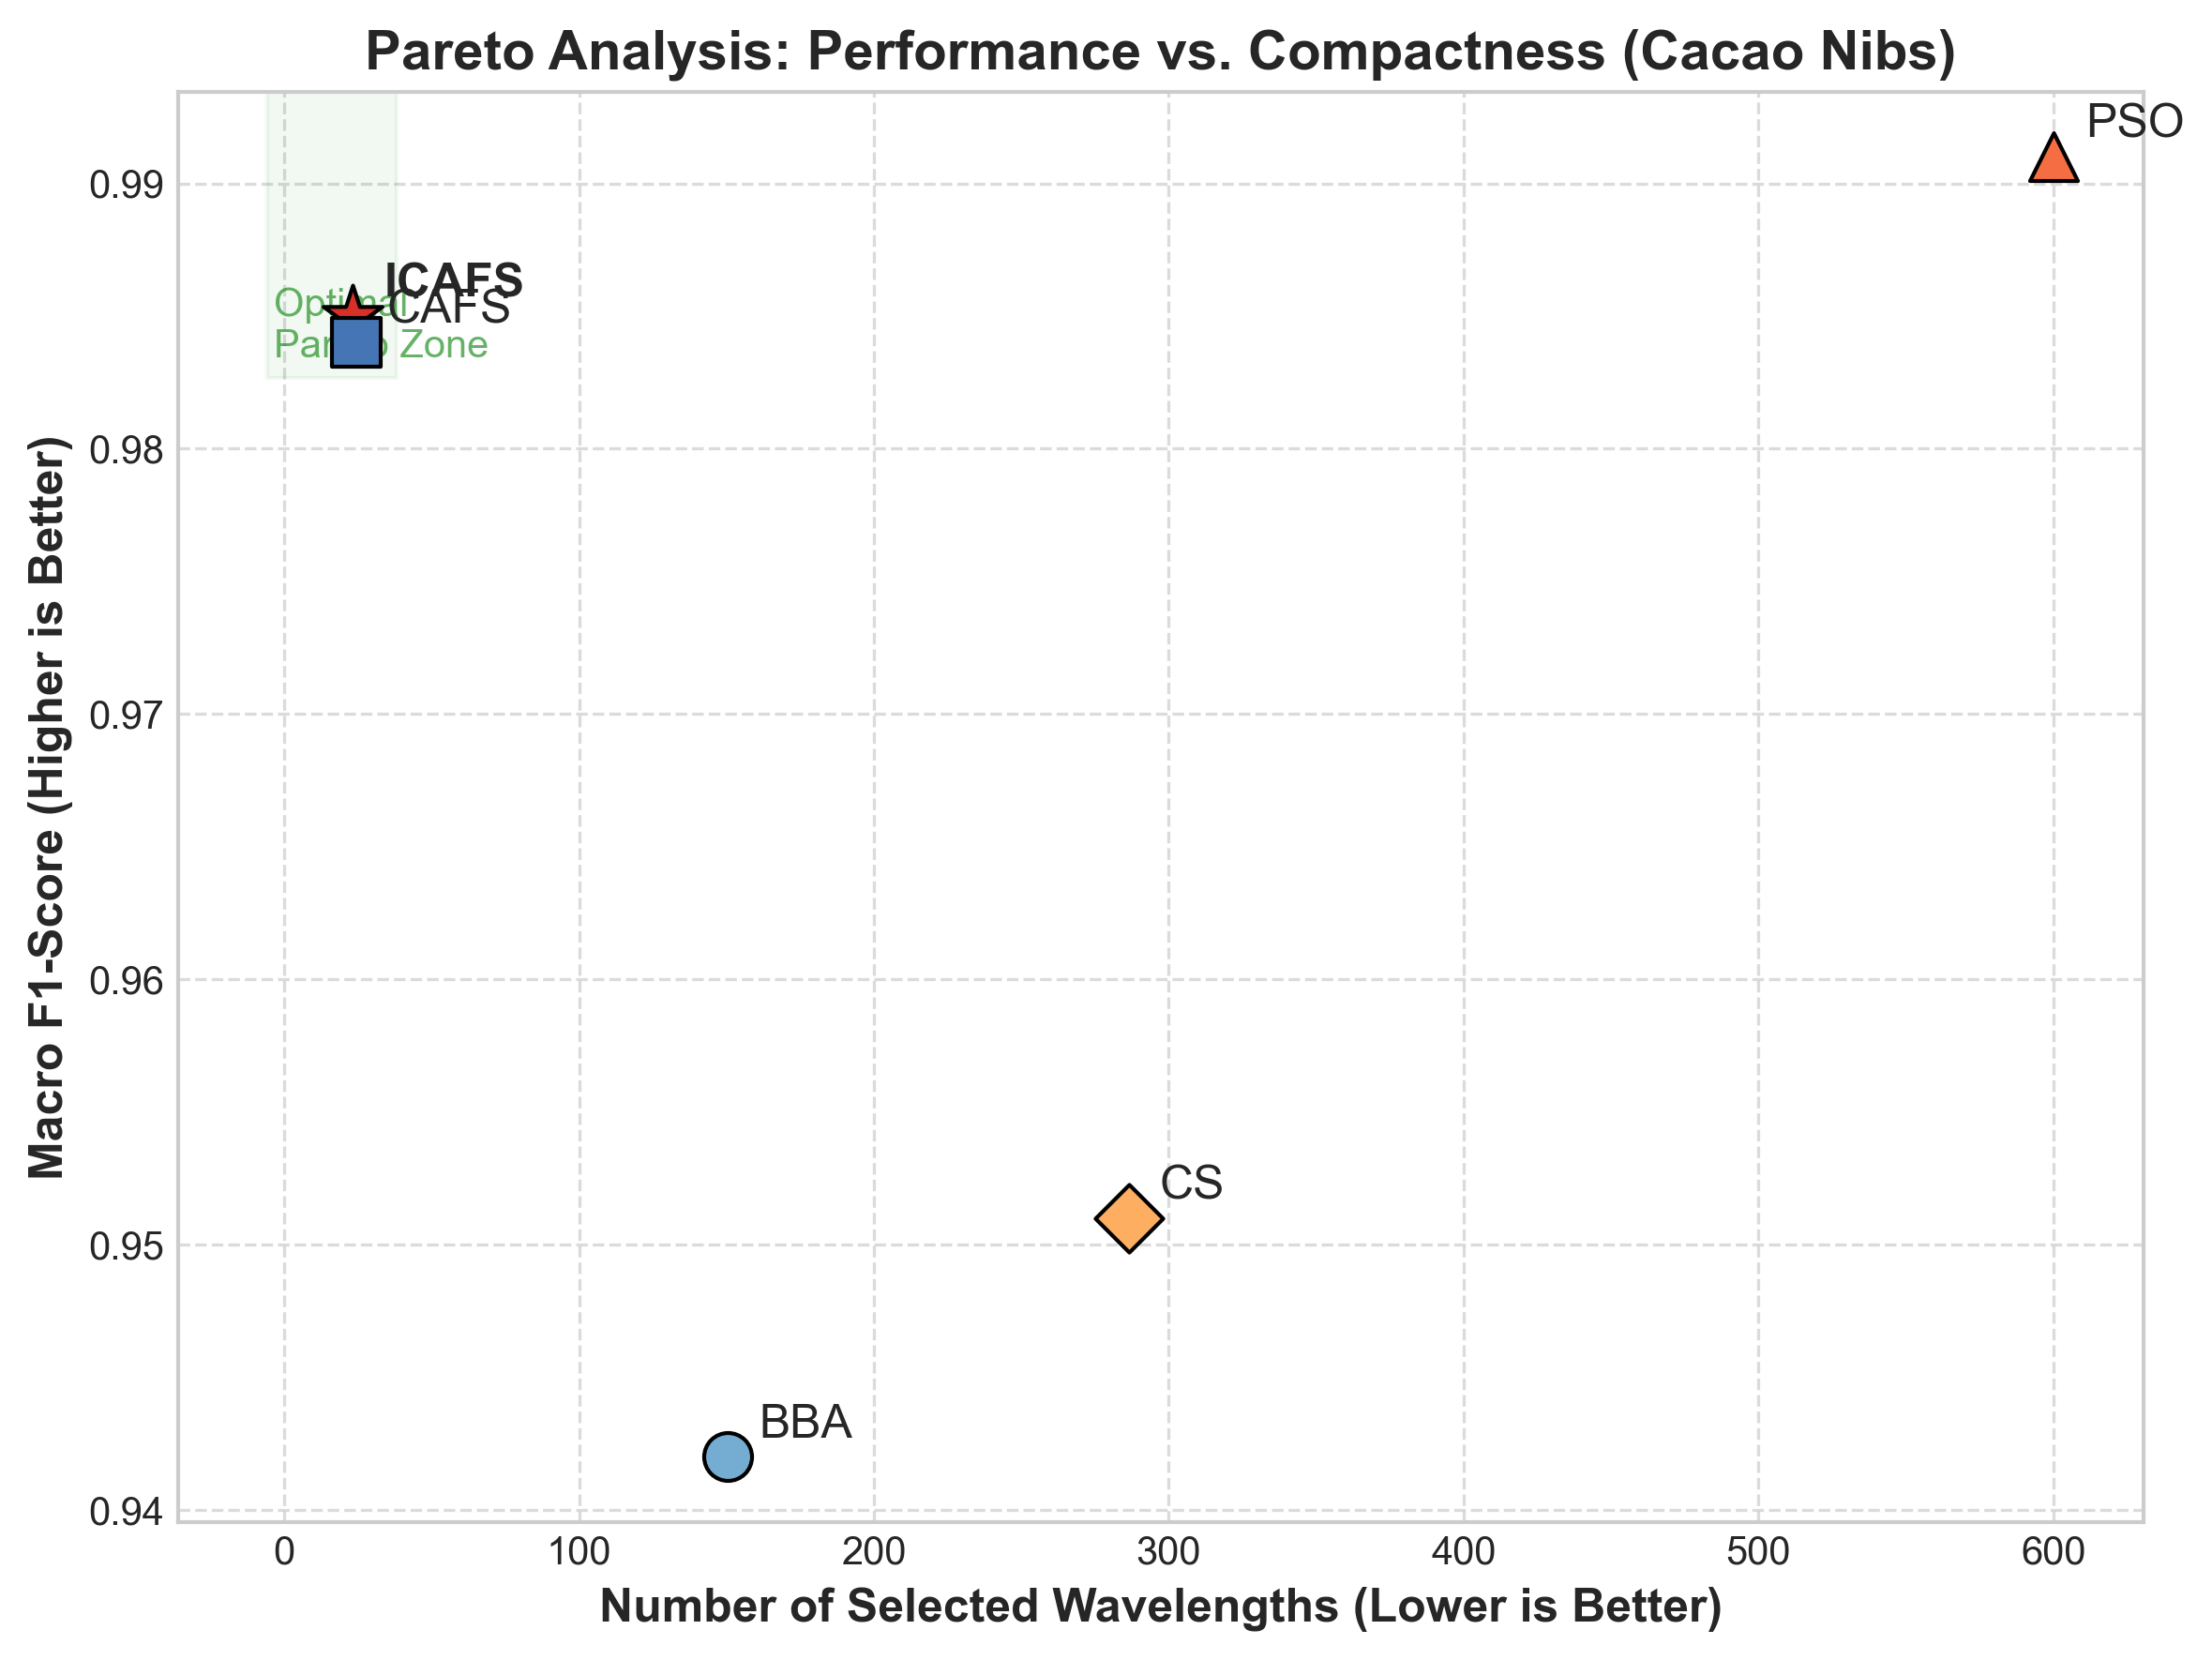

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. INPUT YOUR DATA HERE (Example using hypothetical Cacao Nibs numbers)
# Replace these arrays with the exact numbers from your CSVs for one dataset
algorithms = ['ICAFS', 'CAFS', 'BBA', 'PSO', 'CS']
feature_counts = [23.2, 24.3, 150.5, 600.2, 286.4]  # X-axis data
f1_scores = [0.9850, 0.9840, 0.9420, 0.9910, 0.9510] # Y-axis data

# Define professional colors and markers for IEEE
colors = ['#d73027', '#4575b4', '#74add1', '#f46d43', '#fdae61']
markers = ['*', 's', 'o', '^', 'D']

# 2. CREATE THE PLOT
plt.figure(figsize=(8, 6), dpi=300) # High DPI for publication quality
plt.style.use('seaborn-v0_8-whitegrid')

# Plot each algorithm
for i in range(len(algorithms)):
    # Make ICAFS visually pop by making its marker larger
    size = 250 if algorithms[i] == 'ICAFS' else 150
    plt.scatter(feature_counts[i], f1_scores[i], 
                color=colors[i], marker=markers[i], s=size, 
                edgecolor='black', linewidth=1, label=algorithms[i], zorder=3)
    
    # Add text labels slightly offset from the points
    plt.annotate(algorithms[i], 
                 (feature_counts[i], f1_scores[i]),
                 xytext=(8, 5), 
                 textcoords='offset points',
                 fontsize=12,
                 fontweight='bold' if algorithms[i] == 'ICAFS' else 'normal')

# 3. FORMATTING THE AXES
plt.xlabel('Number of Selected Wavelengths (Lower is Better)', fontsize=12, fontweight='bold')
plt.ylabel('Macro F1-Score (Higher is Better)', fontsize=12, fontweight='bold')
plt.title('Pareto Analysis: Performance vs. Compactness (Cacao Nibs)', fontsize=14, fontweight='bold')

# Draw a subtle shaded box in the top-left to highlight the "Optimal Zone"
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
plt.axvspan(xmin, min(feature_counts) + 15, ymin=0.8, ymax=1, color='green', alpha=0.05, zorder=1)
plt.text(xmin + 2, ymax - 0.01, 'Optimal\nPareto Zone', color='green', fontsize=10, alpha=0.6, zorder=2)

plt.grid(True, linestyle='--', alpha=0.7, zorder=0)
plt.tight_layout()

# 4. SAVE FOR IEEE PUBLICATION
plt.savefig('pareto_plot_cacao.png', format='png', bbox_inches='tight')
plt.show()


# Multiple Seed Experimentation

In [24]:
#datasets = [[df_x_cacao, y_cacao, "Cacao "],[meat_x, y_meat, "Meat"],[olive_x, y_olive, "Olive"],[fruits_pures_x, y_fruit_puree, "Fruit Puree Dataset"],[cis_x,y_cis, "CIS"],[algarrobo_x, y_algarrobo, "Algarrobo"]]
datasets = [[olive_x, y_olive, "Olive"], [df_x_cacao, y_cacao, "Cacao "]]

results = {'Dataset': [], 'BBA': [], 'PSO': [], 'CS': []}
results_feature_numeric = {'Dataset': [], 'BBA': [], 'PSO': [], 'CS': []}
results_features = {'Dataset': [], 'BBA Features': [], 'PSO Features': [], 'CS Features': []}
seed_list = [42, 123, 456, 789, 101112]

for X, y, name in datasets:
    scores, num_of_wavelengths, std_final, std_score_final = evaluate_dataset_nested_seed(X, y, name, seed_list=seed_list)
    
    results['Dataset'].append(name)
    results['BBA'].append(scores['BBA'])
    results['PSO'].append(scores['PSO'])
    results['CS'].append(scores['CS'])

    results_features['Dataset'].append(name)
    results_features['BBA Features'].append(f"{num_of_wavelengths['BBA']:.1f} (± {std_final['BBA']:.1f})")
    results_features['PSO Features'].append(f"{num_of_wavelengths['PSO']:.1f} (± {std_final['PSO']:.1f})")
    results_features['CS Features'].append(f"{num_of_wavelengths['CS']:.1f} (± {std_final['CS']:.1f})")

    results_feature_numeric['Dataset'].append(name)
    results_feature_numeric['BBA'].append(num_of_wavelengths['BBA'])
    results_feature_numeric['PSO'].append(num_of_wavelengths['PSO'])
    results_feature_numeric['CS'].append(num_of_wavelengths['CS'])

# Create a DataFrame for easy viewing and exporting to CSV
df_results = pd.DataFrame(results)
df_results_features = pd.DataFrame(results_features)
df_results_feature_numeric = pd.DataFrame(results_feature_numeric)

print("\n==================================================")
print("FINAL RESULTS TABLE (Phase 3 F1-Scores)")
print("==================================================")
print(df_results.to_string(index=False))

print("\n==================================================")
print("FINAL NUMBER OF FEATURES RESULTS TABLE")
print("==================================================")
print(df_results_features.to_string(index=False))

print("\n==================================================")
print("FINAL NUMBER OF FEATURES RESULTS TABLE (Numeric)")
print("==================================================")
print(df_results_feature_numeric.to_string(index=False))

# Export to CSV so you don't lose the data!
df_results.to_csv('final_f1_scores_revision.csv', index=False)
df_results_features.to_csv('final_features_revision.csv', index=False)
df_results_feature_numeric.to_csv('final_features_numeric_revision.csv', index=False)


Starting NESTED CV for Dataset: Olive

--- Processing Outer Fold 1 / 5 ---
  > Running Feature Selection on Training Data...
  > Running seed 42: Tuning SVMs and Evaluating on Vault Data...
  > Running seed 123: Tuning SVMs and Evaluating on Vault Data...
  > Running seed 456: Tuning SVMs and Evaluating on Vault Data...
  > Running seed 789: Tuning SVMs and Evaluating on Vault Data...
  > Running seed 101112: Tuning SVMs and Evaluating on Vault Data...

  --- Fold 1 Summary (Averaged across 5 seeds) ---
    > BBA: F1 = 0.8438 | Avg Features = 170.0
    > PSO: F1 = 0.8438 | Avg Features = 246.0
    > CS: F1 = 0.8438 | Avg Features = 183.0

--- Processing Outer Fold 2 / 5 ---
  > Running Feature Selection on Training Data...
  > Running seed 42: Tuning SVMs and Evaluating on Vault Data...
  > Running seed 123: Tuning SVMs and Evaluating on Vault Data...
  > Running seed 456: Tuning SVMs and Evaluating on Vault Data...
  > Running seed 789: Tuning SVMs and Evaluating on Vault Data...
  >